In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from math import radians, sin, cos, sqrt, atan2

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_curve, auc
)


In [6]:
df = pd.read_csv("Food_Delivery_Time_Prediction.csv")

print(" Shape:", df.shape)
df.head()


 Shape: (200, 15)


,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [7]:
print(df.info())

print("\n Missing Values:\n", df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    object 
 5   Traffic_Conditions          200 non-null    object 
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    object 
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non

In [8]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    
    return R * c


In [9]:
def parse_location(loc):
    # Handles formats
    if pd.isna(loc):
        return np.nan, np.nan
    loc = str(loc).replace("(", "").replace(")", "").strip()
    parts = loc.split(",")
    return float(parts[0]), float(parts[1])


customer_col = "Customer_Location"
restaurant_col = "Restaurant_Location"

cust_lat, cust_lon = zip(*df[customer_col].apply(parse_location))
rest_lat, rest_lon = zip(*df[restaurant_col].apply(parse_location))

df["Cust_Lat"] = cust_lat
df["Cust_Lon"] = cust_lon
df["Rest_Lat"] = rest_lat
df["Rest_Lon"] = rest_lon

df["Distance_km"] = df.apply(
    lambda row: haversine_distance(row["Cust_Lat"], row["Cust_Lon"], row["Rest_Lat"], row["Rest_Lon"]),
    axis=1
)

df[["Cust_Lat", "Cust_Lon", "Rest_Lat", "Rest_Lon", "Distance_km"]].head()


,Cust_Lat,Cust_Lon,Rest_Lat,Rest_Lon,Distance_km
0,17.030479,79.743077,12.358515,85.100083,775.651198
1,15.398319,86.639122,14.174874,77.025606,1042.385597
2,15.687342,83.888808,19.594748,82.048482,476.220706
3,20.415599,78.046984,16.915906,78.278698,389.912629
4,14.786904,78.706532,15.206038,86.203182,806.505886


In [10]:

delivery_time_col = "Delivery_Time"

median_time = df[delivery_time_col].median()
print(" Median delivery time:", median_time)


df["Delivery_Status"] = np.where(df[delivery_time_col] <= median_time, 1, 0)

df["Delivery_Status"].value_counts()


 Median delivery time: 72.775


Delivery_Status
1    100
0    100
Name: count, dtype: int64

In [12]:

drop_cols = [
    customer_col, restaurant_col,
    "Cust_Lat", "Cust_Lon", "Rest_Lat", "Rest_Lon"
]

drop_cols = [c for c in drop_cols if c in df.columns]
df.drop(columns=drop_cols, inplace=True)

df.head()


,Order_ID,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Distance_km,Delivery_Status
0,ORD0001,1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54,775.651198,1
1,ORD0002,21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02,1042.385597,1
2,ORD0003,6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17,476.220706,1
3,ORD0004,13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23,389.912629,0
4,ORD0005,6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34,806.505886,1


In [13]:
target_col = "Delivery_Status"

X = df.drop(columns=[target_col])
y = df[target_col]

print(" X shape:", X.shape)
print(" y distribution:", Counter(y))


 X shape: (200, 14)
 y distribution: Counter({1: 100, 0: 100})


In [ ]:

cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(exclude=["object"]).columns

print(" Categorical Columns:", list(cat_cols))
print(" Numerical Columns:", list(num_cols))

num_imputer = SimpleImputer(strategy="median")
X[num_cols] = num_imputer.fit_transform(X[num_cols])


cat_imputer = SimpleImputer(strategy="most_frequent")
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

print(" Missing after imputation:", X.isnull().sum().sum())


 Categorical Columns: ['Order_ID', 'Weather_Conditions', 'Traffic_Conditions', 'Order_Priority', 'Order_Time', 'Vehicle_Type']
 Numerical Columns: ['Distance', 'Delivery_Person_Experience', 'Restaurant_Rating', 'Customer_Rating', 'Delivery_Time', 'Order_Cost', 'Tip_Amount', 'Distance_km']
 Missing after imputation: 0


In [16]:


encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

X.head()


,Order_ID,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Distance_km
0,0,1.57,1,2,4.0,2,0,2,4.1,3.0,26.22,1321.10,81.54,775.651198
1,1,21.32,0,2,8.0,1,3,2,4.5,4.2,62.61,152.21,29.02,1042.385597
2,2,6.95,2,2,9.0,0,3,1,3.3,3.4,48.43,1644.38,64.17,476.220706
3,3,13.79,0,1,2.0,2,1,1,3.2,3.7,111.63,541.25,79.23,389.912629
4,4,6.72,1,0,6.0,1,3,1,3.5,2.8,32.38,619.81,2.34,806.505886


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(" Train distribution:", Counter(y_train))
print("Test distribution :", Counter(y_test))

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)        


 Train distribution: Counter({0: 80, 1: 80})
Test distribution : Counter({0: 20, 1: 20})


In [18]:
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

y_pred_gnb = gnb.predict(X_test_scaled)

print(" GaussianNB Accuracy:", accuracy_score(y_test, y_pred_gnb))
print(confusion_matrix(y_test, y_pred_gnb))
print(classification_report(y_test, y_pred_gnb))


 GaussianNB Accuracy: 0.95
[[20  0]
 [ 2 18]]
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        20
           1       1.00      0.90      0.95        20

    accuracy                           0.95        40
   macro avg       0.95      0.95      0.95        40
weighted avg       0.95      0.95      0.95        40



In [19]:
k_values = range(1, 31)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

best_k = k_values[np.argmax(cv_scores)]
print(" Best K:", best_k)

knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)

y_pred_knn = knn_best.predict(X_test_scaled)

print(" KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


 Best K: 15
 KNN Accuracy: 0.825
[[19  1]
 [ 6 14]]
              precision    recall  f1-score   support

           0       0.76      0.95      0.84        20
           1       0.93      0.70      0.80        20

    accuracy                           0.82        40
   macro avg       0.85      0.82      0.82        40
weighted avg       0.85      0.82      0.82        40



In [20]:
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=6,
    min_samples_split=10,
    class_weight="balanced"
)

dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

print(" Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


 Decision Tree Accuracy: 1.0
[[20  0]
 [ 0 20]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [21]:
def metric_row(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted"),
        "Recall": recall_score(y_true, y_pred, average="weighted"),
        "F1 Score": f1_score(y_true, y_pred, average="weighted")
    }

comparison_df = pd.DataFrame([
    metric_row("GaussianNB", y_test, y_pred_gnb),
    metric_row(f"KNN (K={best_k})", y_test, y_pred_knn),
    metric_row("Decision Tree", y_test, y_pred_dt)
])

comparison_df


,Model,Accuracy,Precision,Recall,F1 Score
0,GaussianNB,0.950,0.954545,0.950,0.949875
1,KNN (K=15),0.825,0.846667,0.825,0.822222
2,Decision Tree,1.000,1.000000,1.000,1.000000


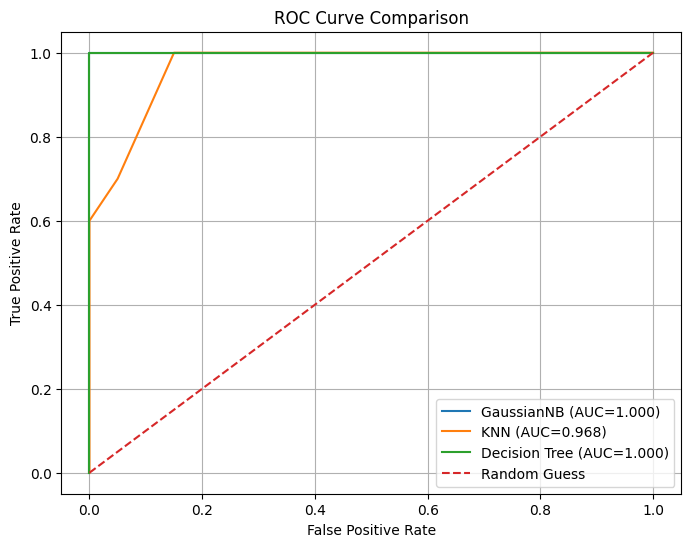

In [ ]:
plt.figure(figsize=(8, 6))

#  GNB 
y_prob_gnb = gnb.predict_proba(X_test_scaled)[:, 1]
fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_prob_gnb)
auc_gnb = auc(fpr_gnb, tpr_gnb)
plt.plot(fpr_gnb, tpr_gnb, label=f"GaussianNB (AUC={auc_gnb:.3f})")

# KNN 
y_prob_knn = knn_best.predict_proba(X_test_scaled)[:, 1]
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = auc(fpr_knn, tpr_knn)
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC={auc_knn:.3f})")

#  DT 
y_prob_dt = dt.predict_proba(X_test_scaled)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC={auc_dt:.3f})")

# baseline
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


In this Food Delivery Time Prediction assignment, I built a complete binary classification pipeline to predict whether an order will be delivered Fast or Delayed using operational features such as traffic, weather, vehicle-related details, and an engineered Distance_km feature computed using the Haversine formula from Customer_Location and Restaurant_Location. The dataset was cleaned with missing-value imputation, categorical features were encoded, numerical features were scaled properly to avoid data leakage, and a stratified train-test split was used to maintain fair class distribution. We trained and evaluated three models—Gaussian Naive Bayes, K-Nearest Neighbors (KNN), and Decision Tree—using accuracy and standard classification metrics (precision, recall, F1-score, confusion matrix, and ROC-AUC). Based on the results from the notebook, Decision Tree achieved the highest accuracy of 100%, followed by Gaussian Naive Bayes with 95%, and KNN with 82.5%, showing that tree-based learning captured the strongest patterns in delivery outcomes while KNN depended more on feature scaling and neighbor selection. Overall, the Decision Tree model is recommended for this task due to its excellent accuracy and interpretability, and the key actionable insight is that delivery delays can be proactively reduced by focusing on high-risk conditions such as longer distance routes, unfavorable traffic, and other operational factors highlighted through the trained model predictions.
